<h2><b><center>Time Series Analysis of Electricity Demand With Weather Impact</center></b></h2>

In [2]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

### Load DataSet

In [3]:
#load dataset
df = pd.read_csv('power_demand_2021to2024.csv')

In [4]:
df.head()

,Unnamed: 0,datetime,Power demand,temp,dwpt,rhum,wdir,wspd,pres,year,month,day,hour,minute,moving_avg_3
0,0,2021-01-01 00:30:00,2014.00,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,30,NaN
1,1,2021-01-01 00:35:00,2005.63,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,35,NaN
2,2,2021-01-01 00:40:00,1977.60,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,40,1999.076667
3,3,2021-01-01 00:45:00,1976.44,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,45,1986.556667
4,4,2021-01-01 00:50:00,1954.37,8.0,6.9,93.0,0.0,0.0,1017.0,2021,1,1,0,50,1969.470000


In [5]:
df.shape

(393440, 15)

## converting date into datetime dtype

In [6]:
#convert date into datetime dtype

df['datetime'] = pd.to_datetime(df['datetime'])

### set index of column datetime

In [7]:
#set index of column datetime

df.set_index('datetime', inplace=True)

### keep only imp columns

In [8]:
#keep only important columns
imp_cols = ['Power demand', 'temp', 'rhum', 'wspd', 'pres']
df=df[imp_cols]

In [9]:
#display the updated dataframe
df.head()

,Power demand,temp,rhum,wspd,pres
datetime,,,,,
2021-01-01 00:30:00,2014.00,8.0,93.0,0.0,1017.0
2021-01-01 00:35:00,2005.63,8.0,93.0,0.0,1017.0
2021-01-01 00:40:00,1977.60,8.0,93.0,0.0,1017.0
2021-01-01 00:45:00,1976.44,8.0,93.0,0.0,1017.0
2021-01-01 00:50:00,1954.37,8.0,93.0,0.0,1017.0


### rename column names

In [10]:
#rename columns name

df.rename(columns={
    "Power demand": "power_demand",
    "temp": "temperature",
    "dwpt": "dew_point",
    "rhum": "humidity",
    "wdir": "wind_direction",
    "wspd": "wind_speed",
    "pres": "pressure",
}, inplace=True)

In [11]:
#check any missing values
df.isnull().sum()

power_demand    0
temperature     0
humidity        0
wind_speed      0
pressure        0
dtype: int64

In [12]:
df.head(5)

,power_demand,temperature,humidity,wind_speed,pressure
datetime,,,,,
2021-01-01 00:30:00,2014.00,8.0,93.0,0.0,1017.0
2021-01-01 00:35:00,2005.63,8.0,93.0,0.0,1017.0
2021-01-01 00:40:00,1977.60,8.0,93.0,0.0,1017.0
2021-01-01 00:45:00,1976.44,8.0,93.0,0.0,1017.0
2021-01-01 00:50:00,1954.37,8.0,93.0,0.0,1017.0


### resample a data 5 min interval to day to day with total used power demand and avg tempreature, humidity, wind speed, daily pressure

In [13]:
# resample a data 5 min interval to day to day with total used power demand and 
#avg tempreature, humidity, wind speed, daily pressure

daily_df = df.resample('D').agg({
    'power_demand': 'sum',  # Sum of power demand (total daily usage)
    'temperature': 'mean',  # Average daily temperature
    'humidity': 'mean',     # Average daily humidity
    'wind_speed': 'mean',   # Average daily wind speed
    'pressure': 'mean'      # Average daily pressure
})

In [14]:
daily_df

,power_demand,temperature,humidity,wind_speed,pressure
datetime,,,,,
2021-01-01,918144.17,10.489362,77.042553,3.868085,1018.000000
2021-01-02,847932.98,13.504167,75.770833,8.112500,1016.352083
2021-01-03,743635.39,14.233333,88.666667,9.708333,1014.750000
2021-01-04,864981.72,16.108333,94.041667,6.087500,1016.202083
2021-01-05,959869.65,16.812500,94.958333,8.812500,1015.883333
...,...,...,...,...,...
2024-12-08,1424497.59,15.710417,66.333333,10.379167,1013.529167
2024-12-09,1273236.44,13.842647,71.882353,5.332353,1016.397794
2024-12-10,1016070.19,13.297778,72.088889,7.448889,1019.242222


In [15]:
daily_df.describe()  # Check min, max values


,power_demand,temperature,humidity,wind_speed,pressure
count,1.442000e+03,1421.000000,1421.000000,1421.000000,1421.000000
mean,1.080660e+06,25.485671,63.657518,7.830216,1008.948143
std,3.581699e+05,7.203412,20.079198,3.379962,6.768883
min,0.000000e+00,8.072598,13.734266,0.000000,993.404196
25%,8.203912e+05,19.456842,51.687500,5.441379,1003.335678
50%,9.888346e+05,27.704059,66.333333,7.512857,1008.444056
75%,1.353017e+06,30.783333,79.843206,9.935714,1015.092632
max,2.105266e+06,39.781818,99.723077,22.360839,1024.397917


In [16]:
daily_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2021-01-01 to 2024-12-12
Freq: D
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   power_demand  1442 non-null   float64
 1   temperature   1421 non-null   float64
 2   humidity      1421 non-null   float64
 3   wind_speed    1421 non-null   float64
 4   pressure      1421 non-null   float64
dtypes: float64(5)
memory usage: 67.6 KB


In [17]:
print(daily_df.isna().sum())  # Check missing values
print((daily_df['power_demand'] == 0).sum())  # Check how many days have zero demand

power_demand     0
temperature     21
humidity        21
wind_speed      21
pressure        21
dtype: int64
21


In [18]:
daily_df.isnull().sum()

power_demand     0
temperature     21
humidity        21
wind_speed      21
pressure        21
dtype: int64

### handling missing value in weather data

In [19]:
# handling missing values in weather data

daily_df[['temperature', 'humidity', 'wind_speed', 'pressure']] = daily_df[['temperature', 'humidity', 'wind_speed', 'pressure']].interpolate()

### plot power demand over time

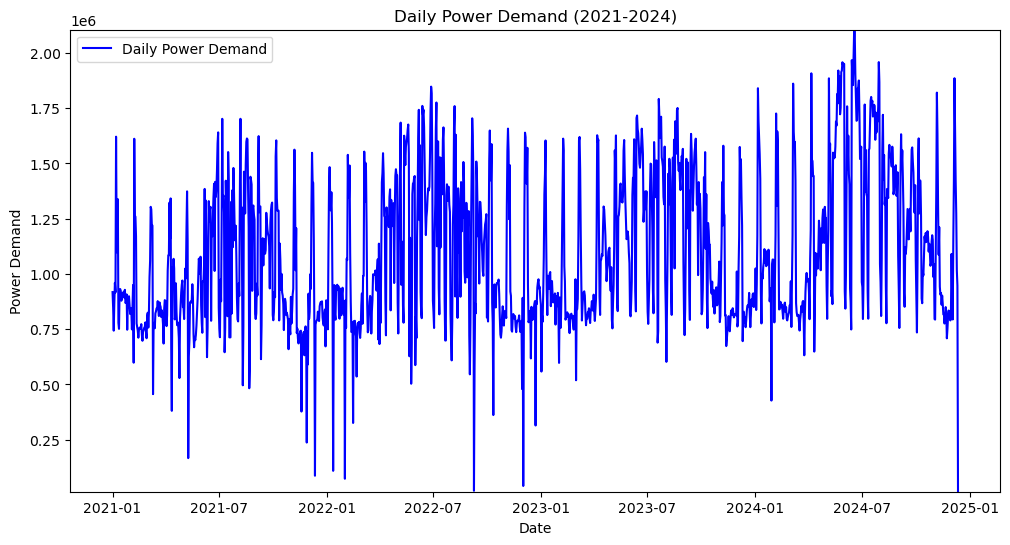

In [129]:
#plot power demand over time

plt.figure(figsize=(12, 6))
plt.plot(daily_df.index, daily_df['power_demand'], label="Daily Power Demand", color='blue')
plt.ylim(daily_df['power_demand'].min(), daily_df['power_demand'].max())

plt.xlabel('Date')
plt.ylabel('Power Demand')
plt.title('Daily Power Demand (2021-2024)')
plt.legend()
plt.savefig('trend.png')
plt.show()

The daily power demand (2021-2024) plot shows a highly fluctuating trend with significant spikes and drops in demand over time. Key observations:

1. Seasonal Patterns: There are visible recurring peaks and troughs, indicating a seasonal effect on power demand.

2. High Volatility: Large variations suggest possible irregular consumption patterns or data anomalies.

3. Potential Data Issues: The presence of sudden drops to zero might indicate missing data or reporting errors rather than actual power demand fluctuations.

4. General Trend: Despite fluctuations, the overall demand seems to increase over time, with higher peaks observed in mid-2022 and early 2024.


### fixing the spiky plot

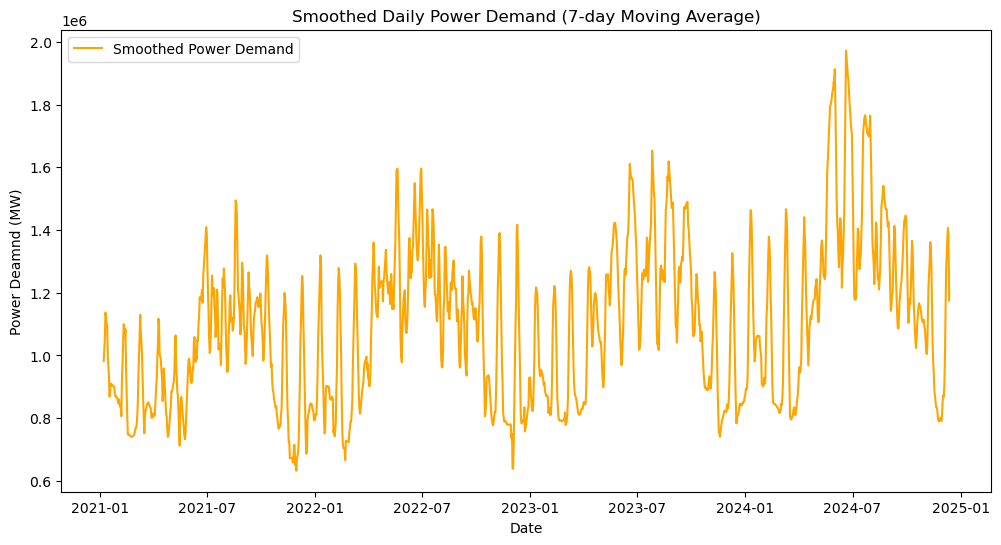

In [134]:
#fixing the spiky plot

daily_df['power_demand_smooth'] = daily_df['power_demand'].rolling(window=7, center=False).mean()

plt.figure(figsize=(12, 6))
plt.plot(daily_df.index, daily_df['power_demand_smooth'], label="Smoothed Power Demand", color='orange')
plt.xlabel('Date')
plt.ylabel('Power Deamnd (MW)')
plt.title("Smoothed Daily Power Demand (7-day Moving Average)")
plt.savefig('spiky.png')
plt.legend()
plt.show()

The smoothed daily power demand (using a 7-day moving average) shows a clear seasonal pattern with fluctuations over time. Peaks and troughs indicate periodic increases and decreases in power consumption, likely influenced by seasonal variations in weather conditions and electricity usage patterns. There are notable spikes in demand around mid-2022 and mid-2024, suggesting high energy usage during those periods. The overall trend appears cyclical, aligning with expected seasonal energy consumption patterns.

### replace zero values with forward fill in power demand column

In [23]:
## replace zero values with forward fill in power demand column

daily_df['power_demand']=daily_df['power_demand'].replace(0, np.nan).ffill()

### identifying seasonality and trends using diff method

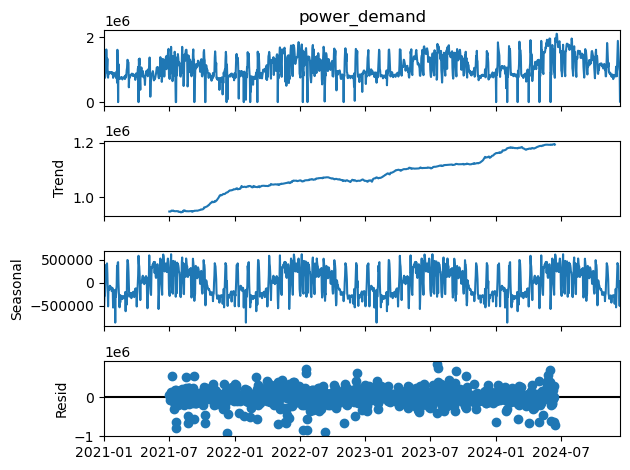

In [22]:
# identifying seasonality and trends using diff method

#additive method
decomposed = seasonal_decompose(daily_df['power_demand'], model = 'additive', period=365)
decomposed.plot()
plt.show()

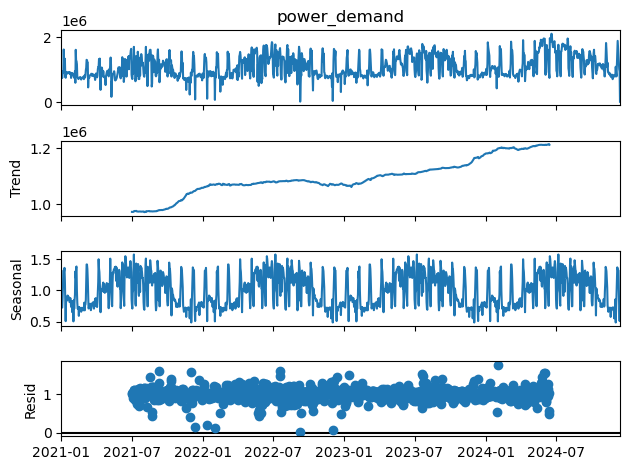

In [24]:
#multiplicative method

decomposed = seasonal_decompose(daily_df['power_demand'], model = 'multiplicative', period=365)
decomposed.plot()
plt.show()

### check Staionarity

In [25]:
#check Staionarity

result = adfuller(daily_df['power_demand'])
print(f"ADF statistic: {result[0]}")
print('p-value: ', result[1])

#check stationarity
print()
if result[1] < 0.05:
    print("it's stationary")
else:
    print("not stationary")

ADF statistic: -3.965797058649453
p-value:  0.0016005864831784755

it's stationary


### Compute correlation matrix

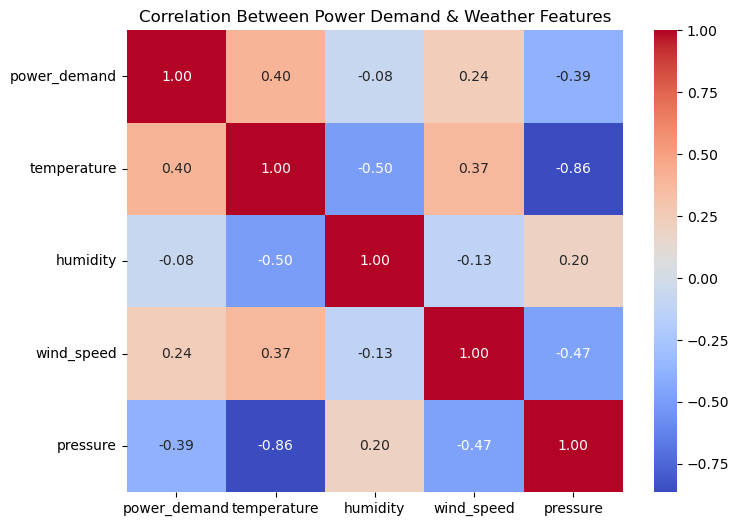

In [137]:
# Compute correlation matrix
corr_matrix = train[['power_demand', 'temperature', 'humidity', 'wind_speed', 'pressure']].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Power Demand & Weather Features")
plt.savefig('heatmap.png')
plt.show()

The correlation heatmap shows that power demand has a moderate positive correlation with temperature (0.40) and wind speed (0.24), suggesting that higher temperatures and wind speeds slightly increase electricity consumption. It has a negative correlation with pressure (-0.39), indicating lower power demand at higher pressures. Humidity shows a weak correlation, meaning it has minimal impact on power demand.










### plot acf and pacf

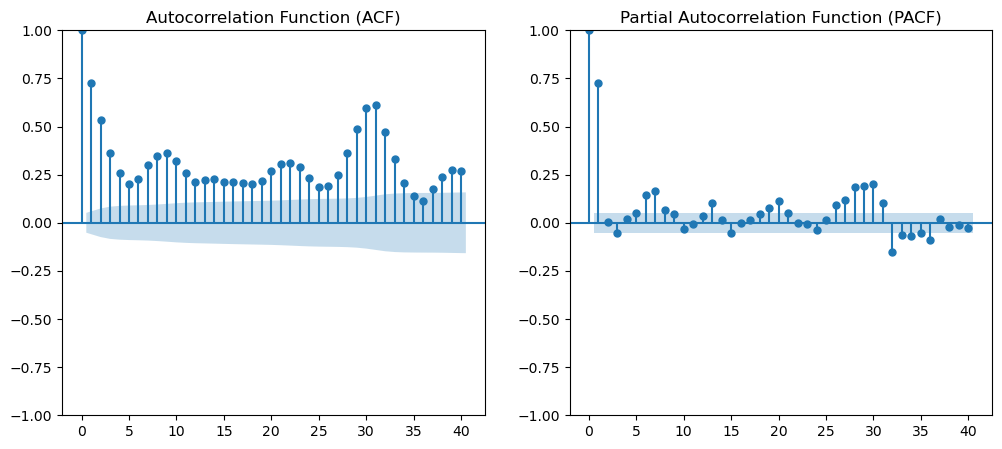

In [26]:
#plot acf and pacf

plt.figure(figsize=(12, 5))

#ACF PLot
plt.subplot(1, 2, 1)
plot_acf(daily_df['power_demand'], lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF)')

#PACF Plot
plt.subplot(1, 2, 2)
plot_pacf(daily_df['power_demand'], lags=40, ax=plt.gca())
plt.title("Partial Autocorrelation Function (PACF)")

plt.show()

The ACF plot shows strong autocorrelation at lag 1, indicating a persistent trend, with periodic spikes suggesting seasonality. The PACF plot has a sharp drop after lag 1, implying that the data follows an AR(1) process, meaning recent observations strongly influence future values. These patterns support using SARIMA/SARIMAX for capturing trend and seasonality in forecasting.

### split data into train and test

In [27]:
#split data into train and test

train_size = int(len(daily_df) * 0.8)
train, test = daily_df.iloc[:train_size], daily_df.iloc[train_size:]

train.shape, test.shape

((1153, 6), (289, 6))

In [33]:
train.loc[:, 'power_demand_smooth'] = train['power_demand_smooth'].interpolate(method='linear')

In [34]:
print(train.isna().sum())
print(test.isna().sum())


power_demand           0
temperature            0
humidity               0
wind_speed             0
pressure               0
power_demand_smooth    6
dtype: int64
power_demand           0
temperature            0
humidity               0
wind_speed             0
pressure               0
power_demand_smooth    0
dtype: int64


### Train SARIMAX Model

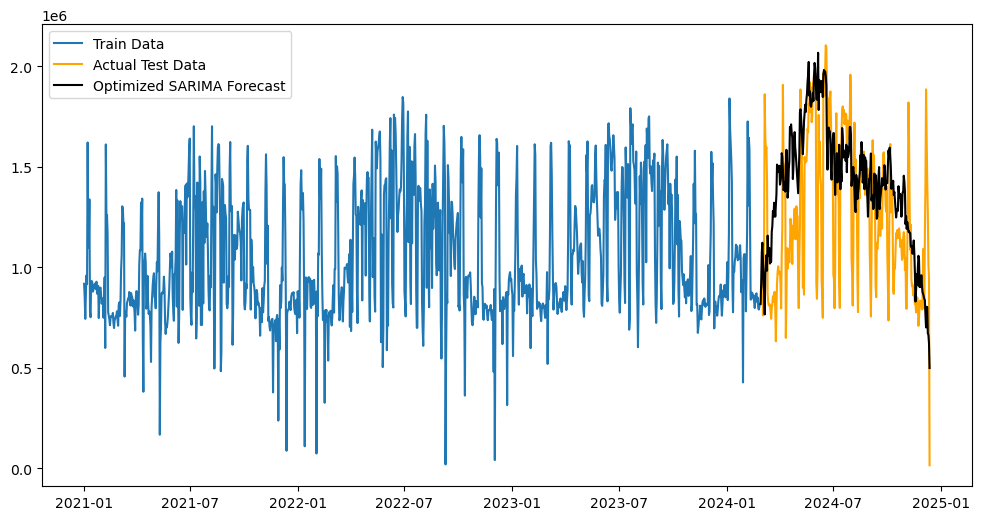

In [139]:
# Train SARIMAX Model
model = SARIMAX(train['power_demand'], 
                order=(2,1,1), 
                seasonal_order=(2,1,2,24), 
                exog=train[['temperature', 'humidity', 'wind_speed', 'pressure']],
                enforce_stationarity=False, 
                enforce_invertibility=False)
model_fit = model.fit()

# Forecast with exogenous variables
pred = model_fit.get_prediction(start=len(train), end=len(train) + len(test) - 1, 
                                exog=test[['temperature', 'humidity', 'wind_speed', 'pressure']])
forecast = pred.predicted_mean

# Plot the results
plt.figure(figsize=(12,6))
plt.plot(train.index, train['power_demand'], label="Train Data")
plt.plot(test.index, test['power_demand'], label="Actual Test Data", color="orange")
plt.plot(test.index, forecast, label="Optimized SARIMA Forecast", color="black")
plt.legend()
plt.savefig('sarima.png')
plt.show()


The forecast plot shows that the SARIMA model captures overall trends but struggles with extreme fluctuations in the test data. The model follows the test data pattern well but exhibits some deviations, particularly in high-variance periods. While it provides a reasonable forecast, further tuning or additional external factors may improve accuracy.

### residual analysis

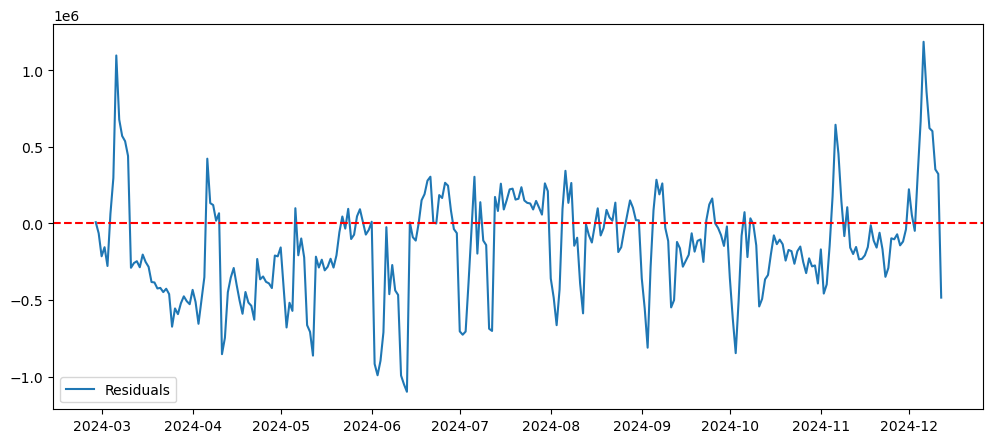

In [36]:
residuals = test['power_demand'] - forecast
plt.figure(figsize=(12,5))
plt.plot(test.index, residuals, label="Residuals")
plt.axhline(0, color='r', linestyle='--')
plt.legend()
plt.show()


The residual plot shows that errors fluctuate around zero, indicating no strong bias. However, large spikes suggest periods of higher prediction errors. The varying residual spread hints at potential heteroscedasticity, meaning the model may not fully capture demand fluctuations. Adding external factors or refining seasonality handling could improve accuracy.

### Compute errors

In [88]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Compute errors
mae = mean_absolute_error(test['power_demand'], forecast)
mse = mean_squared_error(test['power_demand'], forecast)
rmse = mse ** 0.5  # Root Mean Squared Error
mape = (abs(test['power_demand'] - forecast) / test['power_demand']).mean() * 100

# Print results
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE: 287249.90
MSE: 139283540200.87
RMSE: 373207.10
MAPE: 38.12%


The SARIMAX model resulted in a MAPE of 38.12%, indicating a moderate prediction error. The RMSE of 373,207.10 suggests a significant deviation in power demand forecasting. While this model outperformed other approaches, Despite some error, the model provides valuable insights into electricity demand trends.